# 💪 Quando conviene comprare un abbonamento?

**Un modello probabilistico di break-even.**

La domanda sembra banale e si risolve con una divisione:

> abbonamento 50 €/mese, ingresso singolo 10 € → mi conviene se ci vado più di **5 volte al mese**.

Il problema è che questa formula assume una cosa falsa: che tu sappia già quante volte ci andrai.

## 💡 TL;DR

- 🧮 **Break-even "da calcolatrice":** 5 ingressi/mese. È il conto che farebbe chiunque, è troppo ottimista.
- 🎯 **Break-even reale (modello probabilistico):** servono almeno **13 ingressi/mese dichiarati** per avere ≥50% di probabilità che l'abbonamento convenga davvero.
- 🏋️ **Il caso classico** — *"ci vado 2-3 volte a settimana"* (10/mese dichiarati), produce **4,3 ingressi/mese** in media (dato calibrato su uno studio reale, 7.752 iscritti a palestre USA). Probabilità che l'abbonamento convenga: **23%**. Costo reale per ingresso: **11,68 €**, più del carnet a consumo.
- 🚌 **Trasporto pubblico:** qui la calcolatrice quasi ci prende (23 vs 25 corse/mese). Il modello serve dove c'è incertezza sul comportamento, non ovunque.

Nel 2006 DellaVigna e Malmendier hanno pubblicato sull'*American Economic Review* uno studio
su oltre 7.000 iscritti a tre palestre americane, con i dati reali degli ingressi.
Chi sceglieva l'abbonamento mensile flat ci andava in media **4,3 volte al mese**,
pagando di fatto **più di 17 dollari a ingresso**, quando un carnet a consumo ne costava 10.

Quindi la domanda giusta non è *quanto costa la palestra*, ma **quante volte ci andrai davvero**
e quella è una variabile casuale, non un numero.

Il modello è costruito in tre passi:
1. l'utilizzo come **distribuzione di probabilità**, non come costante
2. il **decadimento dell'abitudine** nel tempo
3. una **simulazione Monte Carlo** che restituisce una *probabilità* di convenienza

📄 Paper: DellaVigna, S. & Malmendier, U. (2006). *Paying Not to Go to the Gym*. American Economic Review, 96(3), 694–719.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # seed fisso: risultati riproducibili

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
BLU, ROSSO, GRIGIO = "#2E5EAA", "#C4453C", "#8A8A8A"
print("Setup ok")

Setup ok


---
## 📐 1. Modellare l'utilizzo
Due meccanismi separati, che spesso vengono confusi in uno solo:

**a) Bias di ottimismo.** Quando ti iscrivi sopravvaluti te stesso. Se dici "ci vado 10 volte al mese",
il tuo primo mese reale sarà già più basso di 10.

**b) Decadimento dell'abitudine.** L'entusiasmo iniziale cala e si stabilizza su un plateau.
È la ragione per cui le palestre sono piene a gennaio e vuote a marzo.

La media mensile degli utilizzi diventa quindi:

$$\mu_m = P + (I - P)\cdot d^{\,m}, \qquad I = \text{ottimismo} \times \text{frequenza dichiarata}$$

dove $I$ è il livello iniziale reale, $P$ il plateau e $d$ il fattore di decadimento mensile.

In [3]:
def media_mensile(freq_dichiarata, mesi, ottimismo, decadimento, plateau_frac):
    '''Numero medio di utilizzi per ciascun mese dell'abbonamento.'''
    m = np.arange(mesi)
    iniziale = ottimismo * freq_dichiarata
    plateau  = plateau_frac * iniziale
    return plateau + (iniziale - plateau) * (decadimento ** m)

### La variabilità conta quanto la media

Intorno a quella media, gli utilizzi reali oscillano parecchio: settimane in cui si va quattro volte,
mesi in cui non si va mai (influenza, trasferta, pigrizia).

Uso una **Binomiale Negativa** e non una Poisson. La Poisson impone varianza = media,
ipotesi troppo rigida per un comportamento umano. La Binomiale Negativa permette
**sovradispersione**:

$$\text{Var} = \mu + \frac{\mu^2}{r}$$

Il parametro $r$ regola quanto sei irregolare: $r$ basso = molto irregolare, $r \to \infty$ = torna Poisson.

In [4]:
def simula_utilizzi(freq_dichiarata, mesi=12, dispersione=2.0, n_sim=20_000,
                    ottimismo=0.75, decadimento=0.85, plateau_frac=0.18):
    '''
    Simula n_sim 'vite possibili' dell'abbonamento.
    Ritorna una matrice (n_sim x mesi) di utilizzi.
    '''
    mu = media_mensile(freq_dichiarata, mesi, ottimismo, decadimento, plateau_frac)
    r  = dispersione
    p  = np.broadcast_to(r / (r + mu), (n_sim, mesi))
    return rng.negative_binomial(r, p)

### Calibrazione sui dati reali

I parametri comportamentali sono scelti in modo che il modello riproduca
il dato osservato nello studio, **10 visite/mese attese → 4,3 reali** in media sull'anno.

In [5]:
PALESTRA_BEHAV = dict(ottimismo=0.75, decadimento=0.85, plateau_frac=0.18)

curva_media = media_mensile(10, 12, **PALESTRA_BEHAV)
print("Media utilizzi mese per mese:", np.round(curva_media, 2))
print(f"\nMedia sui 12 mesi: {curva_media.mean():.2f}   (target dal paper: 4.3)")

Media utilizzi mese per mese: [7.5  6.58 5.79 5.13 4.56 4.08 3.67 3.32 3.03 2.77 2.56 2.38]

Media sui 12 mesi: 4.28   (target dal paper: 4.3)


---
## 💶 2. I costi

Due sole funzioni. Il confronto è tra spendere l'abbonamento fisso e pagare ogni singolo utilizzo.

In [6]:
def costo_abbonamento(prezzo_mensile, mesi):
    return prezzo_mensile * mesi

def costo_pay_per_use(utilizzi, prezzo_unitario):
    return utilizzi.sum(axis=1) * prezzo_unitario

def analizza(freq, prezzo_mensile, prezzo_unitario, mesi=12, **kw):
    '''Simula e confronta. risparmio > 0 significa che l'abbonamento ha convenuto.'''
    u     = simula_utilizzi(freq, mesi=mesi, **kw)
    c_abb = costo_abbonamento(prezzo_mensile, mesi)
    c_ppu = costo_pay_per_use(u, prezzo_unitario)
    risp  = c_ppu - c_abb
    tot   = u.sum(axis=1)
    return dict(
        freq=freq,
        media_mese=u.mean(),
        tot_medio=tot.mean(),
        p_conviene=(risp > 0).mean(),
        risp_medio=risp.mean(),
        p5=np.percentile(risp, 5),
        p95=np.percentile(risp, 95),
        costo_utilizzo=c_abb / tot.mean(),
        risparmio=risp,
    )

---
## 🧮 3. Il break-even "da calcolatrice"

Quello che si farebbe di norma, ed è il termine di paragone.

In [7]:
PREZZO_MENSILE  = 50     # euro/mese
PREZZO_INGRESSO = 10     # euro a ingresso
MESI            = 12

break_even_det = PREZZO_MENSILE / PREZZO_INGRESSO
print(f"Break-even deterministico: {break_even_det:.0f} ingressi al mese")

Break-even deterministico: 5 ingressi al mese


---
## 🎲 4. Il break-even probabilistico

Per ogni possibile frequenza dichiarata simulo 20.000 anni di abbonamento e conto
**in quale frazione di casi l'abbonamento è stato la scelta giusta**.

Il risultato è una curva.

In [8]:
def curva_probabilita(prezzo_mensile, prezzo_unitario, mesi=12, freqs=range(1, 26), **kw):
    righe = []
    for f in freqs:
        r = analizza(f, prezzo_mensile, prezzo_unitario, mesi, **kw)
        righe.append({k: v for k, v in r.items() if k != "risparmio"})
    return pd.DataFrame(righe)

def soglia(df, livello):
    ok = df[df.p_conviene >= livello]
    return None if ok.empty else int(ok.freq.iloc[0])

df = curva_probabilita(PREZZO_MENSILE, PREZZO_INGRESSO, MESI, range(1, 26), **PALESTRA_BEHAV)

s50, s80, s90 = soglia(df, .50), soglia(df, .80), soglia(df, .90)
print(f"Break-even deterministico      : {break_even_det:.0f} ingressi/mese")
print(f"Serve dichiararne {s50} per avere P >= 50%")
print(f"Serve dichiararne {s80} per avere P >= 80%")
print(f"Serve dichiararne {s90} per avere P >= 90%")

df[["freq", "media_mese", "p_conviene", "risp_medio", "costo_utilizzo"]].round(2)

Break-even deterministico      : 5 ingressi/mese
Serve dichiararne 13 per avere P >= 50%
Serve dichiararne 15 per avere P >= 80%
Serve dichiararne 17 per avere P >= 90%


,freq,media_mese,p_conviene,risp_medio,costo_utilizzo
0,1,0.43,0.00,-548.87,117.34
1,2,0.86,0.00,-496.82,58.15
2,3,1.28,0.00,-445.93,38.94
3,4,1.71,0.00,-394.91,29.26
4,5,2.15,0.00,-342.51,23.30
5,6,2.57,0.00,-291.17,19.43
6,7,2.99,0.01,-241.18,16.72
7,8,3.42,0.05,-189.26,14.61
8,9,3.84,0.12,-139.24,13.02
9,10,4.27,0.23,-87.74,11.71


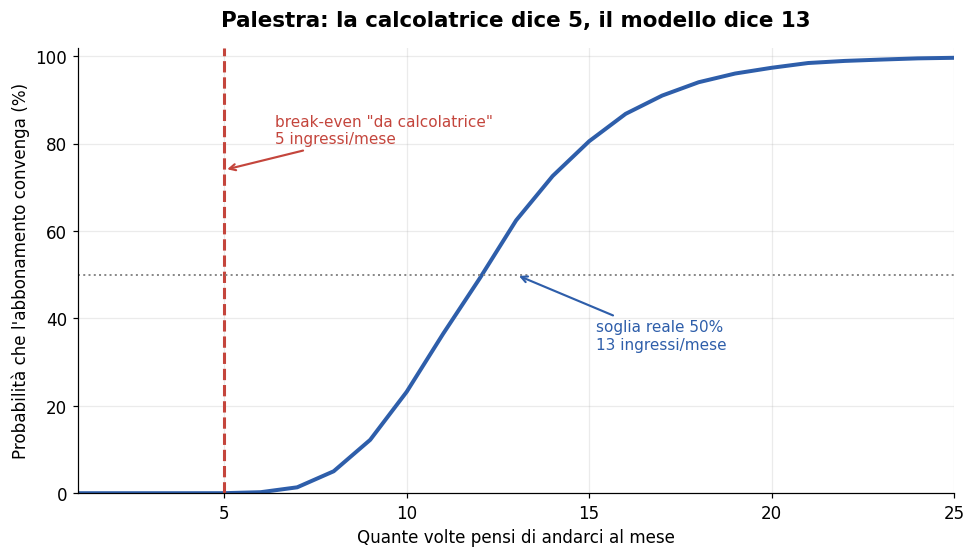

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(df.freq, df.p_conviene * 100, color=BLU, lw=2.6)
ax.axvline(break_even_det, color=ROSSO, ls="--", lw=2)
ax.axhline(50, color=GRIGIO, ls=":", lw=1.3)

ax.annotate(f'break-even "da calcolatrice"\n{break_even_det:.0f} ingressi/mese',
            xy=(break_even_det, 74), xytext=(break_even_det + 1.4, 80),
            color=ROSSO, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=ROSSO, lw=1.4))
ax.annotate(f"soglia reale 50%\n{s50} ingressi/mese",
            xy=(s50, 50), xytext=(s50 + 2.2, 33), color=BLU, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=BLU, lw=1.4))

ax.set_xlabel("Quante volte pensi di andarci al mese")
ax.set_ylabel("Probabilità che l'abbonamento convenga (%)")
ax.set_title(f"Palestra: la calcolatrice dice {break_even_det:.0f}, il modello dice {s50}",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xlim(1, 25); ax.set_ylim(0, 102)
plt.tight_layout(); plt.show()

### Il caso classico: "ci vado due o tre volte a settimana"

Sono circa 10 ingressi al mese. È la frase che si dice maggiormente al momento dell'iscrizione.

In [10]:
r10 = analizza(10, PREZZO_MENSILE, PREZZO_INGRESSO, MESI, **PALESTRA_BEHAV)

print(f"Dichiarati              : 10 ingressi/mese")
print(f"Reali (media modello)   : {r10['media_mese']:.2f}/mese → {r10['tot_medio']:.0f} in 12 mesi")
print(f"P(abbonamento conviene) : {r10['p_conviene']:.1%}")
print(f"Costo reale per ingresso: {r10['costo_utilizzo']:.2f} € (contro i {PREZZO_INGRESSO} € del singolo)")
print(f"Risparmio medio         : {r10['risp_medio']:+.0f} €")
print(f"Intervallo 5°–95° perc. : {r10['p5']:+.0f} € / {r10['p95']:+.0f} €")

Dichiarati              : 10 ingressi/mese
Reali (media modello)   : 4.28/mese → 51 in 12 mesi
P(abbonamento conviene) : 23.0%
Costo reale per ingresso: 11.68 € (contro i 10 € del singolo)
Risparmio medio         : -86 €
Intervallo 5°–95° perc. : -290 € / +150 €


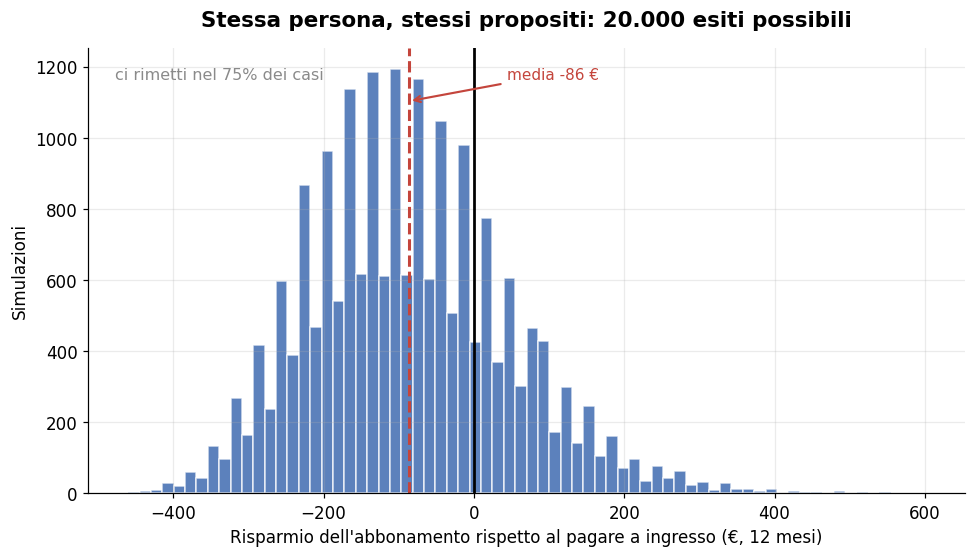

In [11]:
r = r10["risparmio"]

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.hist(r, bins=70, color=BLU, alpha=.78, edgecolor="white", lw=.4)
ax.axvline(0, color="black", lw=1.8)
ax.axvline(r.mean(), color=ROSSO, ls="--", lw=2)
ax.annotate(f"media {r.mean():+.0f} €", xy=(r.mean(), ax.get_ylim()[1]*.88),
            xytext=(r.mean() + 130, ax.get_ylim()[1]*.93), color=ROSSO, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=ROSSO, lw=1.4))
ax.text(.03, .93, f"ci rimetti nel {(r < 0).mean()*100:.0f}% dei casi",
        transform=ax.transAxes, fontsize=10.5, color=GRIGIO)

ax.set_xlabel("Risparmio dell'abbonamento rispetto al pagare a ingresso (€, 12 mesi)")
ax.set_ylabel("Simulazioni")
ax.set_title("Stessa persona, stessi propositi: 20.000 esiti possibili",
             fontsize=14, fontweight="bold", pad=14)
plt.tight_layout(); plt.show()

### Dove nasce il divario

Il break-even deterministico sbaglia perché confronta il prezzo con i **propositi**,
non con il **comportamento** "reale".

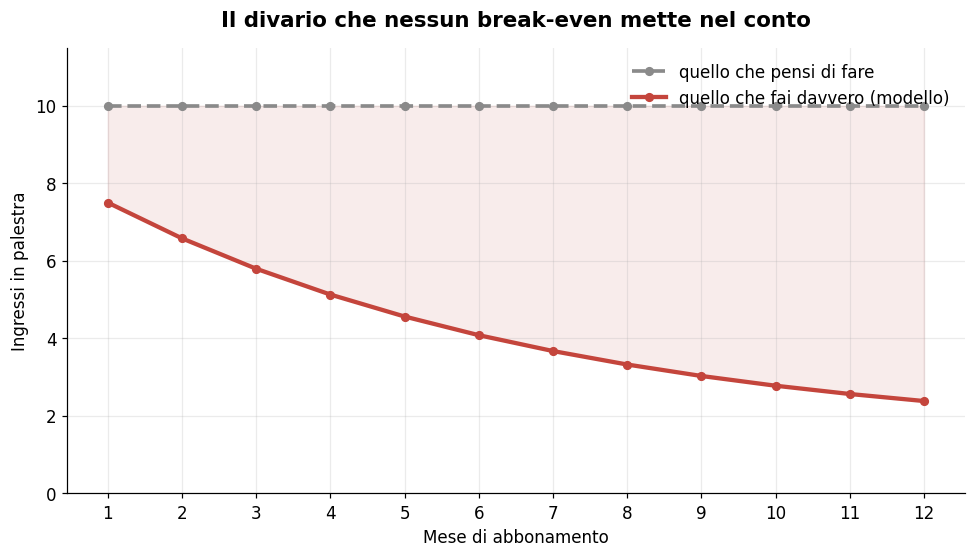

In [12]:
mesi_ax = np.arange(1, 13)
previsto = np.full(12, 10.0)
reale    = media_mensile(10, 12, **PALESTRA_BEHAV)

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.plot(mesi_ax, previsto, color=GRIGIO, lw=2.4, ls="--", marker="o", ms=5,
        label="quello che pensi di fare")
ax.plot(mesi_ax, reale, color=ROSSO, lw=2.8, marker="o", ms=5,
        label="quello che fai davvero (modello)")
ax.fill_between(mesi_ax, reale, previsto, color=ROSSO, alpha=.10)

ax.set_xticks(mesi_ax)
ax.set_xlabel("Mese di abbonamento"); ax.set_ylabel("Ingressi in palestra")
ax.set_title("Il divario che nessun break-even mette nel conto",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(frameon=False, loc="upper right"); ax.set_ylim(0, 11.5)
plt.tight_layout(); plt.show()

---
## 🚌 5. Controprova: il trasporto pubblico

Se il modello dicesse "non comprare mai un abbonamento" sarebbe solo un modello pessimista.

Il pendolare è il caso opposto: prende il mezzo per andare al lavoro, quindi si conosce bene
(niente ottimismo) e non smette a marzo (niente decadimento). Cambiano solo i parametri
comportamentali, il codice è identico.

In [13]:
TRASPORTO_BEHAV = dict(ottimismo=0.98, decadimento=0.99, plateau_frac=0.90)

T_MENSILE, T_CORSA = 35, 1.5
be_t = T_MENSILE / T_CORSA

dft = curva_probabilita(T_MENSILE, T_CORSA, MESI, range(5, 51), **TRASPORTO_BEHAV)
rt  = analizza(42, T_MENSILE, T_CORSA, MESI, **TRASPORTO_BEHAV)   # 2 corse x 21 gg

print(f"Break-even deterministico : {be_t:.1f} corse/mese")
print(f"Soglia P >= 50%           : {soglia(dft, .50)} corse/mese")
print(f"Soglia P >= 90%           : {soglia(dft, .90)} corse/mese")
print(f"\nPendolare tipo (42 corse/mese): P(conviene) = {rt['p_conviene']:.1%}, "
      f"risparmio medio {rt['risp_medio']:+.0f} €")

Break-even deterministico : 23.3 corse/mese
Soglia P >= 50%           : 25 corse/mese
Soglia P >= 90%           : 33 corse/mese

Pendolare tipo (42 corse/mese): P(conviene) = 99.2%, risparmio medio +316 €


Qui la soglia probabilistica (25) è quasi identica a quella deterministica (23,3):
quando il comportamento è prevedibile, **la calcolatrice basta**.
Il modello serve dove c'è incertezza, non ovunque.

---
## 🔁 6. Quanto dipende dalle mie ipotesi?

Faccio variare i due parametri più discutibili, l'ottimismo e l'irregolarità, e guardo se la conclusione regge.

In [14]:
righe = []
for ott in (0.65, 0.75, 0.85, 1.00):
    for disp in (1.0, 2.0, 5.0):
        b = dict(PALESTRA_BEHAV); b["ottimismo"] = ott
        d = curva_probabilita(PREZZO_MENSILE, PREZZO_INGRESSO, MESI,
                              range(1, 31), dispersione=disp, **b)
        righe.append({"ottimismo": ott, "dispersione": disp,
                      "soglia_50%": soglia(d, .50),
                      "soglia_90%": soglia(d, .90)})

sens = pd.DataFrame(righe)
print("Break-even deterministico (invariato):", int(break_even_det), "ingressi/mese\n")
sens.pivot(index="ottimismo", columns="dispersione", values="soglia_50%")

Break-even deterministico (invariato): 5 ingressi/mese



dispersione,1.0,2.0,5.0
ottimismo,,,
0.65,15,14,14
0.75,13,13,12
0.85,11,11,11
1.00,10,9,9


Anche nel caso più generoso, nessun bias di ottimismo e comportamento molto regolare, la soglia resta **sopra** il break-even deterministico. La direzione del risultato non dipende
dalla calibrazione: il calcolo semplice sottostima **sempre** quanto devi usare un servizio
perché l'abbonamento convenga.

---
# 🔧 Estensione: dati recenti, abbandono e contratti reali

Il modello fin qui ha tre limiti espliciti, e li affronto uno per uno:

| Limite | Cosa aggiungo |
|---|---|
| Calibrazione su dati del 2006 | Confronto con i dati di settore 2024-2025 |
| Ipotesi che tu resti iscritto 12 mesi | **Abbandono**: la maggioranza smette prima |
| Prezzi illustrativi, nessun vincolo contrattuale | Contratti reali del mercato italiano: vincoli, quote di attivazione, promozioni |

Il terzo è il più interessante, perché è quello che ribalta la conclusione.

## 📅 7. I dati del 2006 valgono ancora?

Il paper originale è del 2006. I dati di settore più recenti raccontano una storia
un po' diversa: la frequenza media per iscritto si è attestata **intorno a 1,5 visite
a settimana nel 2024** (circa 6,5 al mese), in calo rispetto alle 2,1 del 2019 ma
comunque sopra il 4,3 del paper.

Invece di scegliere un numero, calibro **due regimi** e confronto le soglie.

In [15]:
BEHAV_2006 = dict(ottimismo=0.75, decadimento=0.85, plateau_frac=0.18)  # -> 4.3/mese
BEHAV_2024 = dict(ottimismo=0.90, decadimento=0.90, plateau_frac=0.45)  # -> ~7.0/mese

for nome, b in [("Calibrazione 2006 (paper)", BEHAV_2006),
                ("Calibrazione 2024 (settore)", BEHAV_2024)]:
    m = media_mensile(10, 12, **b)
    print(f"{nome:30s} -> media reale {m.mean():.2f} ingressi/mese")

Calibrazione 2006 (paper)      -> media reale 4.28 ingressi/mese
Calibrazione 2024 (settore)    -> media reale 7.01 ingressi/mese


### Prezzi reali invece che illustrativi

Passo anche ai prezzi veri del mercato italiano 2025 (catene low-cost):
abbonamento vincolato **34,90 €/mese**, formula senza vincolo **49,90 €/mese**,
quota di attivazione **39 €**, ingresso singolo **15 €**.

In [16]:
P_INGRESSO = 15.0          # ingresso singolo, mercato italiano
P_VINCOLATO = 34.90        # abbonamento con vincolo 12 mesi
P_FLEX = 49.90             # abbonamento senza vincolo
ATTIVAZIONE = 39.0         # quota una tantum, quasi sempre dimenticata nei conti

for etichetta, b in [("2006", BEHAV_2006), ("2024", BEHAV_2024)]:
    s50 = None
    for f in range(1, 41):
        u = simula_utilizzi(f, **b)
        conviene = ((u.sum(1) * P_INGRESSO) - (P_VINCOLATO * 12 + ATTIVAZIONE)) > 0
        if conviene.mean() >= .5:
            s50 = f
            break
    print(f"Calibrazione {etichetta}: soglia 50% = {s50} ingressi/mese dichiarati")

be = (P_VINCOLATO * 12 + ATTIVAZIONE) / P_INGRESSO / 12
print(f"\nBreak-even da calcolatrice: {be:.1f} ingressi/mese")

Calibrazione 2006: soglia 50% = 7 ingressi/mese dichiarati
Calibrazione 2024: soglia 50% = 4 ingressi/mese dichiarati

Break-even da calcolatrice: 2.5 ingressi/mese


Con i dati recenti la soglia scende parecchio: le persone vanno in palestra più di
quanto facessero nel 2006, e a 15 € a ingresso l'abbonamento diventa più difendibile.
**Il gap con il break-even deterministico resta**, ma si assottiglia.

Questo è un risultato che indebolisce la mia tesi iniziale, e va detto:
il modello serve a capire, non a vincere una discussione.

## 🚪 8. L'abbandono

Finora ho assunto che una persona resti iscritta per 12 mesi. È l'ipotesi meno realistica di tutte.

Secondo il *Benchmarking Report 2025* della Health & Fitness Association — calcolato su
175 aziende e oltre 17.000 strutture in 27 paesi, dati 2024, la **retention annua media
del settore è del 66,4%**: circa un iscritto su tre se ne va ogni anno.
Per i *nuovi* iscritti la situazione è peggiore: la stima più citata dal settore parla
di circa **metà degli iscritti che molla entro sei mesi**.

Le due cifre sembrano contraddirsi, ma misurano popolazioni diverse: il 66,4% è su tutta
la base iscritti (inclusi i veterani fedeli), il 50% riguarda chi si è appena iscritto.
Modello entrambi come scenari separati, senza sceglierne uno.

In [17]:
def simula_abbandono(n_sim, mesi=12, retention_12m=None, hazard_early=None):
    '''
    Mese in cui la persona smette del tutto (mesi = non smette).
    - retention_12m: hazard costante (dato HFA su tutta la base iscritti)
    - hazard_early : hazard decrescente, alto nei primi mesi (nuovo iscritto)
    '''
    if hazard_early is None:
        h = np.full(mesi, 1 - retention_12m ** (1 / mesi))
    else:
        h0, decad = hazard_early
        h = h0 * (decad ** np.arange(mesi))
    esce = rng.random((n_sim, mesi)) < h
    return np.where(esce.any(axis=1), esce.argmax(axis=1), mesi)


def simula_con_abbandono(freq, behav, mesi=12, dispersione=2.0, n_sim=20_000, churn=None):
    '''Come simula_utilizzi, ma dopo l'abbandono la frequenza va a zero.'''
    u = simula_utilizzi(freq, mesi=mesi, dispersione=dispersione, n_sim=n_sim, **behav)
    if churn is None:
        return u, np.full(n_sim, mesi)
    attivo = np.arange(mesi)[None, :] < churn[:, None]
    return u * attivo, churn


for nome, kw in [("Nessun abbandono", None),
                 ("HFA 2025 (66,4% a 12 mesi)", dict(retention_12m=0.664)),
                 ("Nuovo iscritto", dict(hazard_early=(0.16, 0.88)))]:
    ch = None if kw is None else simula_abbandono(20_000, 12, **kw)
    if ch is None:
        print(f"{nome:28s} -> resta 12 mesi: 100.0%")
    else:
        print(f"{nome:28s} -> resta 12 mesi: {(ch >= 12).mean():5.1%} | "
              f"esce entro 6 mesi: {(ch < 6).mean():5.1%}")

Nessun abbandono             -> resta 12 mesi: 100.0%
HFA 2025 (66,4% a 12 mesi)   -> resta 12 mesi: 66.2% | esce entro 6 mesi: 18.8%
Nuovo iscritto               -> resta 12 mesi: 32.7% | esce entro 6 mesi: 53.7%


## 📜 9. I contratti veri: vincoli, attivazione, promozioni

Qui sta il punto. Un abbonamento non è "un prezzo al mese": è un **contratto**,
e la struttura del contratto cambia chi paga cosa. Modello quattro formule realmente
in commercio in Italia (2025):

| Formula | Costo | Vincolo |
|---|---|---|
| **Flex** | 49,90 €/mese | nessuno, disdici quando vuoi |
| **Standard 12 mesi** | 34,90 €/mese | paghi tutti i 12 mesi |
| **Annuale prepagato** | 358,80 € in un'unica soluzione | nessuna uscita |
| **Promo "primi 3 mesi a 10 €"** | poi 34,90 €/mese | vincolo 12 mesi |

Più la **quota di attivazione** (39-49,90 €), che nessuno mette mai nei conti.

Il meccanismo chiave: **col vincolo si continua a pagare anche dopo aver smesso di andare.**
Il modello ora cattura esattamente questo.

In [18]:
CONTRATTI = {
    "Flex (no vincolo)":   dict(mensile=49.90, attivazione=39.0,  vincolo=False, promo=None),
    "Standard 12 mesi":    dict(mensile=34.90, attivazione=39.0,  vincolo=True,  promo=None),
    "Annuale prepagato":   dict(mensile=358.80/12, attivazione=49.90, vincolo=True, promo=None),
    "Promo 3 mesi a 10€":  dict(mensile=34.90, attivazione=39.0,  vincolo=True,  promo=(3, 10.0)),
}

def costo_contratto(cfg, mese_stop, mesi=12):
    '''Col vincolo paghi tutti i mesi; senza vincolo solo quelli in cui sei attivo.'''
    n = len(mese_stop)
    mensilita = np.full(n, mesi) if cfg["vincolo"] else np.minimum(mese_stop + 1, mesi)
    tariffa = np.full((n, mesi), cfg["mensile"])
    if cfg["promo"]:
        n_promo, prezzo_promo = cfg["promo"]
        tariffa[:, :n_promo] = prezzo_promo
    attivo = np.arange(mesi)[None, :] < mensilita[:, None]
    return (tariffa * attivo).sum(axis=1) + cfg["attivazione"]


def confronta_contratti(freq, behav, churn_kw, prezzo_ingresso=15.0, n_sim=20_000):
    ch = None if churn_kw is None else simula_abbandono(n_sim, 12, **churn_kw)
    u, stop = simula_con_abbandono(freq, behav, n_sim=n_sim, churn=ch)
    c_ppu, tot = u.sum(1) * prezzo_ingresso, u.sum(1)
    return pd.DataFrame([{
        "contratto": nome,
        "costo_medio": (c := costo_contratto(cfg, stop)).mean(),
        "p_conviene_vs_ingressi": ((c_ppu - c) > 0).mean(),
        "costo_per_ingresso": c.mean() / tot.mean(),
    } for nome, cfg in CONTRATTI.items()])


for nome, kw in [("NESSUN ABBANDONO", None),
                 ("ABBANDONO MEDIO — HFA 2025", dict(retention_12m=0.664)),
                 ("NUOVO ISCRITTO — ~50% entro 6 mesi", dict(hazard_early=(0.16, 0.88)))]:
    print(f"\n=== {nome} ===")
    print(confronta_contratti(10, BEHAV_2024, kw)
          .to_string(index=False, float_format=lambda x: f"{x:8.2f}"))


=== NESSUN ABBANDONO (ipotesi ingenua) ===
         contratto  costo_medio  p_conviene_vs_ingressi  costo_per_ingresso
 Flex (no vincolo)       637.80                    0.99                7.57
  Standard 12 mesi       457.80                    1.00                5.44
 Annuale prepagato       408.70                    1.00                4.85
Promo 3 mesi a 10€       383.10                    1.00                4.55

=== ABBANDONO MEDIO — HFA 2025 ===
         contratto  costo_medio  p_conviene_vs_ingressi  costo_per_ingresso
 Flex (no vincolo)       540.73                    0.92                7.82
  Standard 12 mesi       457.80                    0.86                6.62
 Annuale prepagato       408.70                    0.87                5.91
Promo 3 mesi a 10€       383.10                    0.88                5.54

=== NUOVO ISCRITTO — ~50% entro 6 mesi ===
         contratto  costo_medio  p_conviene_vs_ingressi  costo_per_ingresso
 Flex (no vincolo)       370.60         

### Il paradosso del vincolo

Guarda la colonna `costo_per_ingresso` nell'ultimo scenario. Il contratto **più economico
sulla carta** (promo, 34,90 → di fatto 383 € l'anno) diventa **il più caro per ingresso**
non appena metti l'abbandono nel modello. Il Flex a 49,90 €/mese, quello che sembra
la fregatura, è il più conveniente per chi molla presto, perché smetti di pagare
quando smetti di andare.

Il punto di inversione è calcolabile esattamente.

Vincolato 12 mesi con promo, totale: 383.10 €
Il Flex diventa più caro dal mese  : 7
Nuovi iscritti che escono prima    : 56.9%


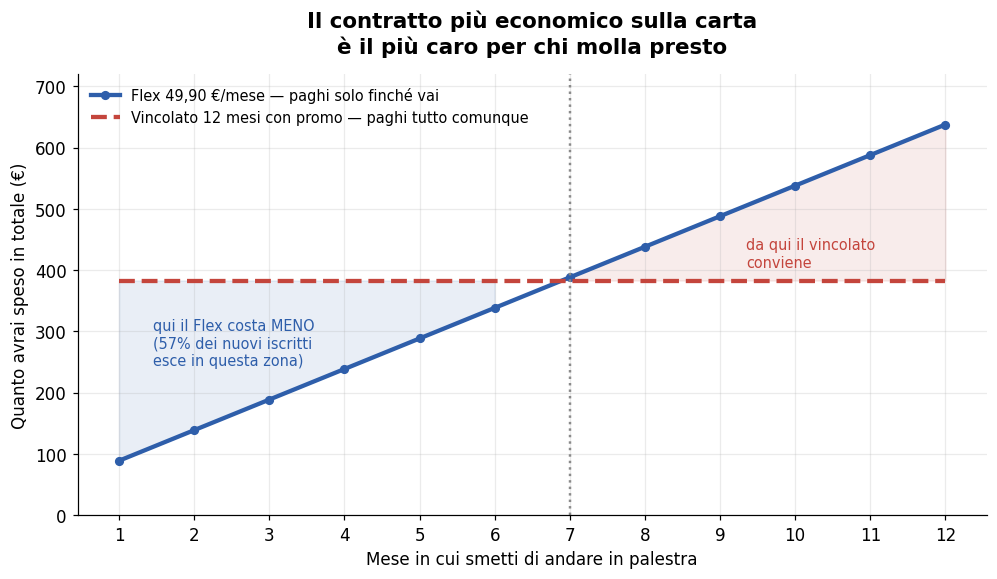

In [19]:
mesi_ax = np.arange(1, 13)
costo_flex  = 39.0 + 49.90 * mesi_ax                       # paghi solo finché vai
costo_promo = np.full(12, 3*10.0 + 9*34.90 + 39.0)         # paghi tutto comunque

inversione = int(np.ceil((costo_promo[0] - 39.0) / 49.90))
ch = simula_abbandono(200_000, 12, hazard_early=(0.16, 0.88))
p_esce_prima = (ch < inversione).mean()

print(f"Vincolato 12 mesi con promo, totale: {costo_promo[0]:.2f} €")
print(f"Il Flex diventa più caro dal mese  : {inversione}")
print(f"Nuovi iscritti che escono prima    : {p_esce_prima:.1%}")

fig, ax = plt.subplots(figsize=(9.2, 5.4))
ax.plot(mesi_ax, costo_flex, color=BLU, lw=2.8, marker="o", ms=5,
        label="Flex 49,90 €/mese — paghi solo finché vai")
ax.plot(mesi_ax, costo_promo, color=ROSSO, lw=2.8, ls="--",
        label="Vincolato 12 mesi con promo — paghi tutto comunque")
ax.axvline(inversione, color=GRIGIO, ls=":", lw=1.6)
ax.fill_between(mesi_ax, costo_flex, costo_promo, where=costo_flex < costo_promo,
                color=BLU, alpha=.10)
ax.fill_between(mesi_ax, costo_flex, costo_promo, where=costo_flex >= costo_promo,
                color=ROSSO, alpha=.10)
ax.annotate(f"qui il Flex costa MENO\n({p_esce_prima:.0%} dei nuovi iscritti\nesce in questa zona)",
            xy=(1.45, 245), fontsize=9.5, color=BLU)
ax.annotate("da qui il vincolato\nconviene", xy=(9.35, 405), fontsize=9.5, color=ROSSO)
ax.set_xticks(mesi_ax)
ax.set_xlabel("Mese in cui smetti di andare in palestra")
ax.set_ylabel("Quanto avrai speso in totale (€)")
ax.set_title("Il contratto più economico sulla carta\nè il più caro per chi molla presto",
             fontsize=14, fontweight="bold", pad=14)
ax.legend(frameon=False, loc="upper left", fontsize=9.5)
ax.set_ylim(0, 720)
plt.tight_layout(); plt.show()

### Perché le promozioni funzionano (per la palestra)

La promo "primi 3 mesi a 10 €" è una delle due leve più efficaci del settore, e il modello
mostra perché: sconta proprio i mesi in cui la motivazione è ancora alta e la frequenza
è al massimo. Quando la promo finisce, mese 4, si è nella finestra in cui la frequenza
crolla, ma il vincolo contrattuale tiene dentro per altri otto mesi a tariffa piena.

E' un contratto legittimo, e per chi effettivamente frequenta è
**il più conveniente di tutti**. Ma il conto che si fa al momento della firma
(*"10 € al mese, un affare"*) descrive tre mesi su dodici.

⚖️ Nota: in Italia i contratti a distanza o negoziati fuori dai locali commerciali
prevedono un **diritto di recesso di 14 giorni**; i contratti firmati in sede non lo prevedono
per legge, salvo diversa previsione contrattuale.

---
## 🏁 Conclusioni

**Quattro cose che il modello dice e la divisione no:**

1. **Il break-even semplice è ottimista per costruzione.** Ignora che l'utilizzo è incerto,
   e l'incertezza è asimmetrica: puoi andarci molto meno del previsto, difficilmente molto di più.

2. **La risposta è una probabilità (vedi curva), non un sì/no.** Con i prezzi italiani reali e la
   calibrazione recente il quadro è meno drastico che nel paper del 2006, ma il gap
   con il calcolo deterministico resta.

3. **La domanda vera non è "quale abbonamento costa meno", ma "quanto durerò".**
   Il contratto più economico sulla carta è il più caro per ingresso non appena metti
   l'abbandono nel modello. Il punto di inversione tra Flex e vincolato cade intorno
   al **settimo mese**, e circa il **57% dei nuovi iscritti esce prima**.

4. **Il modello serve dove c'è incertezza sul comportamento, non ovunque.**
   Per il pendolare la calcolatrice funziona benissimo (23 vs 25 corse/mese).

### ⚠️ Limiti

- Il modello sceglie tra abbonamento e ingressi singoli su un **orizzonte fisso di 12 mesi**.
  Non ottimizza la scelta nel tempo (es. Flex per i primi mesi e poi passaggio all'annuale
  una volta verificata l'abitudine), che è probabilmente la strategia migliore nella realtà.
- I parametri di frequenza sono calibrati su fonti eterogenee: un paper accademico del 2006
  e statistiche di settore recenti, alcune delle quali pubblicate da fornitori di software
  per palestre e quindi non peer-reviewed. La cifra sulla retention (66,4%) è la più solida.
- Il tasso di abbandono per i nuovi iscritti (~50% entro 6 mesi) è una stima largamente
  citata nel settore ma di provenienza meno rigorosa rispetto al dato HFA.
- Modello solo il costo monetario. Restano fuori la comodità di non pensare a pagare
  ogni volta, l'effetto motivazionale del vincolo, sospensioni e congelamenti,
  cessione del contratto a terzi, e le penali di disdetta anticipata.
- I prezzi sono quelli di catene low-cost italiane nel 2025: cambiano per città,
  struttura e periodo dell'anno.

### 📄 Fonti

- DellaVigna, S. & Malmendier, U. (2006). *Paying Not to Go to the Gym*.
  American Economic Review, 96(3), 694–719.
- Health & Fitness Association, *2025 Fitness Industry Benchmarking Report*
  (retention annua 66,4%, 175 aziende e oltre 17.000 strutture in 27 paesi, dati 2024).
- Condizioni contrattuali e listini pubblici di catene fitness italiane, 2025.